# Daily Eddy Kinematic Properties

In [2]:
from smode_import import *
from parula import parula

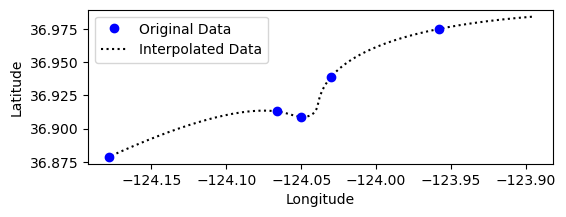

In [3]:
# interpolate eddy core position 
ds = xr.open_dataset('dopplerscatt_gridded.nc')
ds = ds.sel(time=slice('2023-04-19','2023-04-23'), lat=slice(36.7,37.1), lon=slice(-124.25,-123.8))

lats_slice = [slice(36.9,37), slice(36.9,37), slice(36.85,36.95), slice(36.85,36.95), slice(36.85,36.9)]
lons_slice = [slice(-124,-123.9), slice(-124.1,-124), slice(-124.1,-124,), slice(-124.1,-124.0), slice(-124.2,-124.1)]

max_vor_lats = []
max_vor_lons = []
max_vor_times= []

for i in range(ds.sizes['time']):
    dsi = ds.vorticity.isel(time=i).sel(lat=lats_slice[i],lon=lons_slice[i])
    max_vor = dsi.where(dsi==dsi.max(), drop=True).squeeze()
    max_vor_lats.append(max_vor.lat)
    max_vor_lons.append(max_vor.lon)
    max_vor_times.append(dsi.time.values)

    #plt.figure()
    #ds.vorticity.isel(time=i).plot()
    #plt.plot(max_vor.lon, max_vor.lat, 'ok')

# Convert lists to arrays
max_vor_lats = np.array(max_vor_lats)
max_vor_lons = np.array(max_vor_lons)
max_vor_times = np.array(max_vor_times)

# Create DataArrays
lat_da = xr.DataArray(max_vor_lats, coords=[max_vor_times], dims=['time'], name='lat')
lon_da = xr.DataArray(max_vor_lons, coords=[max_vor_times], dims=['time'], name='lon')

# Combine into a Dataset
ds_max_vorticity = xr.Dataset({'lat': lat_da, 'lon': lon_da})

# Interpolate to hourly timestamps
start_time = pd.Timestamp(str(ds_max_vorticity.time.min().values)) - pd.Timedelta(days=0.5)
end_time = pd.Timestamp(str(ds_max_vorticity.time.max().values))

hourly_times = pd.date_range(start=start_time, end=end_time, freq='0.3h')
hourly_times

ds_max_vorticity['time'] = pd.to_datetime(ds_max_vorticity['time'].values)

# Interpolate to hourly timestamps
ds_interpolated = ds_max_vorticity.interp(time=hourly_times, method='quadratic', kwargs={"fill_value": "extrapolate"})

# Plotting the interpolated positions
plt.figure(figsize=(6,2))
plt.plot(ds_max_vorticity['lon'], ds_max_vorticity['lat'], 'bo', label='Original Data',zorder=101)
plt.plot(ds_interpolated['lon'], ds_interpolated['lat'], 'k:', label='Interpolated Data')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()

plt.show()


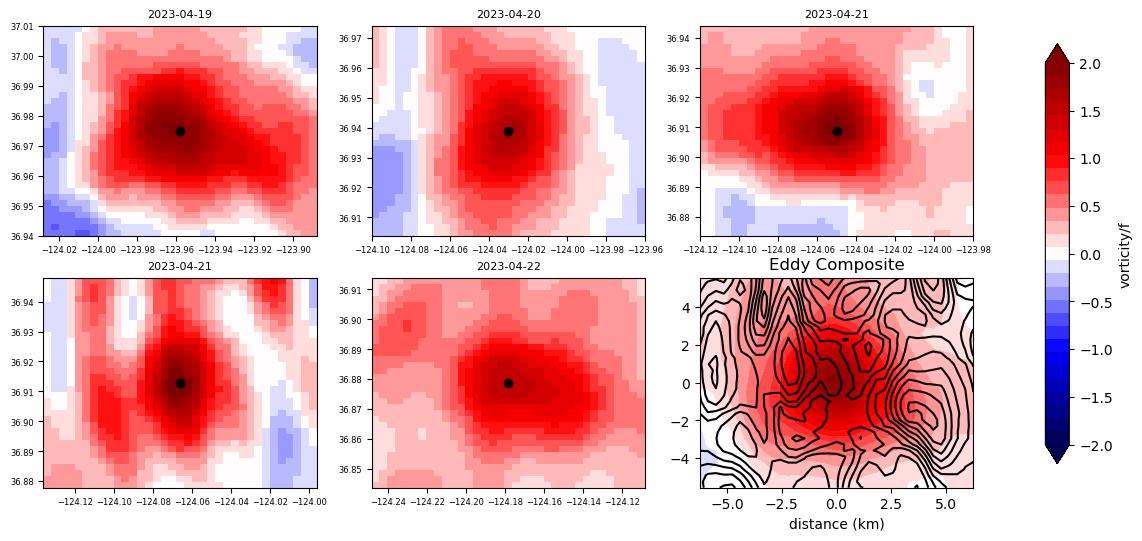

In [4]:
# create eddy composite
var = 'vorticity'
if var=='divergence': vmin,vmax=-1,1
elif var=='vorticity': vmin,vmax=-2,2
elif var=='w_ek': vmin,vmax=-3e-4,3e-4; itimes=[11,12,13,14,15]
elif var=='okuboweiss': vmin,vmax=-4e-4,4e-4;

cmap='seismic'

eddy_mid_value=[]
eddy_all = []

fig, ax = plt.subplots(2,3,figsize=(12,6))

for i in range(ds.sizes['time']):
    if var=='w_ek':
        dsi = xr.open_dataset('dopplerscatt_w_ekman_gridded.nc').isel(time=itimes[i]).w_tot
    else: 
        f=coriolis_parameter(35)
        dsi = ds[var].isel(time=i)/f
    lat=ds_max_vorticity.isel(time=i).lat
    lon=ds_max_vorticity.isel(time=i).lon

    f = coriolis_parameter(35)

    dlat,dlon=0.05,0.07
    eddy = dsi.sel(lat=slice(lat-dlat,lat+dlat),lon=slice(lon-dlon,lon+dlon))
    eddy = eddy[7:-7,:]
    eddy_all.append(eddy)
        
    # keep divergence value
    L=len(eddy)
    mid = int(np.round(L/2))
    eddy_mid_value.append(eddy[mid,mid].values)
    
    # plot each eddy
    axis=ax.flatten()[i]
    eddy.plot(levels=np.linspace(vmin,vmax,30), cmap=cmap, extend='both', add_colorbar=False, ax=axis)
    axis.plot(dsi.sel(lat=lat,lon=lon).lon, dsi.sel(lat=lat,lon=lon).lat, 'ok')
    axis.set_title(str(eddy.time.values)[0:10],fontsize=8)
    axis.tick_params(axis='x', labelsize=6); axis.tick_params(axis='y', labelsize=6);
    axis.set_xlabel(''); axis.set_ylabel('')

eddy_all = np.array(eddy_all)
eddy_composite_mean = eddy_all.mean(0)
eddy_composite_std = eddy_all.std(0)

# x/y coordinates of composite
xlat=np.linspace(0,dlat*2,len(eddy.lat))
xlon=np.linspace(0,dlon*2,len(eddy.lon))
y_eddy = xlat * 111320 / 1e3
lat_midpoint = (eddy.lat[0] + eddy.lat[-1]) / 2  # Use the midpoint latitude for conversion
x_eddy = xlon * (111320 * np.cos(np.radians(lat_midpoint.values))) / 1e3

# plot eddy composite
axis=ax.flatten()[-1]
p=axis.contourf(x_eddy-np.mean(x_eddy),y_eddy-np.mean(y_eddy),eddy_composite_mean,np.linspace(vmin,vmax,30),cmap=cmap,extend='both')
axis.contour(x_eddy-np.mean(x_eddy),y_eddy-np.mean(y_eddy),eddy_composite_std,10,colors='k')
axis.set_title('Eddy Composite')
axis.set_xlabel('distance (km)')

cbar_ax = fig.add_axes([0.96, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
cbar=fig.colorbar(p, cax=cbar_ax)
cbar.set_ticks(np.linspace(vmin,vmax,9))
if var=='w_ek': cbar.set_label(f'{var}')
else: cbar.set_label(f'{var}/f')

#plt.savefig(f'/Users/elise/ocean/drifters_chl/figures/eddy/composite-{var}.png',dpi=800)

plt.show();

/var/folders/vw/s5yfsczj0nzgw4mcs35y8c9r0000gp/T/ipykernel_43811/2432304613.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


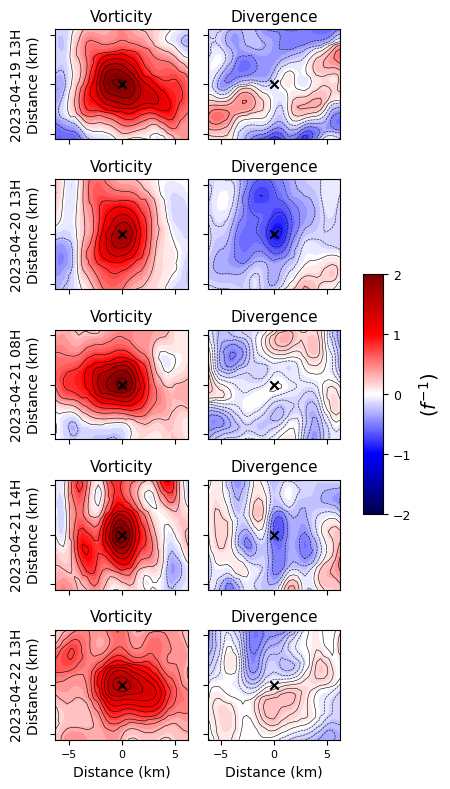

In [19]:
# --- SETTINGS ---
vars_to_plot = ['vorticity', 'divergence']
vmin, vmax = -2, 2  # shared color scale
cmap = 'seismic'
nrows = 5

fig, axes = plt.subplots(nrows, 2, figsize=(4, 8), sharex=True, sharey=True)

for i in range(nrows):  # loop over time steps
    lat = ds_max_vorticity.isel(time=i).lat
    lon = ds_max_vorticity.isel(time=i).lon
    f = coriolis_parameter(35)
    dlat, dlon = 0.05, 0.07

    for j, var in enumerate(vars_to_plot):
        ax = axes[i, j]
        field = ds[var].isel(time=i) / f
        eddy = field.sel(lat=slice(lat - dlat, lat + dlat),
                         lon=slice(lon - dlon, lon + dlon))[7:-7, :]

        # Coordinates for km axis
        xlat = np.linspace(0, dlat * 2, len(eddy.lat))
        xlon = np.linspace(0, dlon * 2, len(eddy.lon))
        lat_mid = (eddy.lat[0] + eddy.lat[-1]) / 2
        y_km = xlat * 111320 / 1e3
        x_km = xlon * (111320 * np.cos(np.radians(lat_mid.values))) / 1e3

        p = ax.contourf(x_km - x_km.mean(), y_km - y_km.mean(), eddy,
                        levels=np.linspace(vmin, vmax, 50), cmap=cmap, extend='both')
        ax.contour(x_km - x_km.mean(), y_km - y_km.mean(), eddy,
                        levels=10, colors='k', linewidths=0.4)
        ax.scatter(0,0, marker='x', c='k')
        if j == 0:
            ax.set_ylabel(f"{str((pd.Timestamp(str(eddy.time.values))-np.timedelta64(7,'h')))[:13]}H\nDistance (km)", fontsize=10)
        else:
            ax.set_yticklabels([])
        if i == nrows - 1:
            ax.set_xlabel('Distance (km)', fontsize=10)

        ax.set_title(var.capitalize(), fontsize=11)
        ax.tick_params(labelsize=8)

# Shared colorbar
cbar_ax = fig.add_axes([0.92, 0.35, 0.05, 0.3])  # [left, bottom, width, height]
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin, vmax))
cbar = fig.colorbar(sm, cax=cbar_ax, ticks=np.linspace(vmin, vmax, 5))
cbar.ax.tick_params(labelsize=9)
cbar.set_label(r'($f^{-1}$)', fontsize=14)

plt.tight_layout(rect=[0, 0, 0.9, 1])

plt.savefig('/Users/elise/ocean/drifters_chl/high-res/supp/daily-snapshots.png',dpi=800, bbox_inches='tight')
plt.show()


In [15]:
pd.Timestamp(str(eddy.time.values))-np.timedelta64(7,'h')

Timestamp('2023-04-22 13:10:41')

Timestamp('2023-04-19 20:25:05')